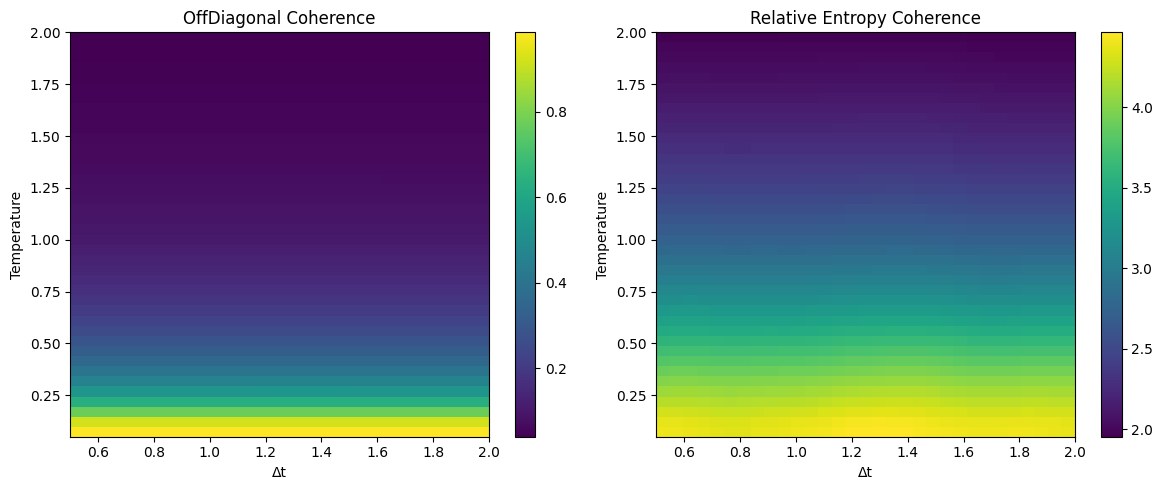

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Parameters must match your saving script ---
n_max = 2
N_spins = 6
omega1 = 1.0
omega2 = 1.0
J = -1.0
delta = 0.5
tau_1 = 0.05
tau_2 = 0.05
final_evolution_time = 2.0

temperature_list = np.arange(0.05, 2.05, 0.05)
delta_t_list = np.arange(0.5, 2.05, 0.05)

# --- Arrays to hold coherence values ---
offdiag_vals = np.zeros((len(temperature_list), len(delta_t_list)))
relentropy_vals = np.zeros((len(temperature_list), len(delta_t_list)))

# --- Load saved coherence values ---
for i, Temp_spin in enumerate(temperature_list):
    for j, delta_t in enumerate(delta_t_list):
        filename_rho = (
            f"rho_evolved_Nspins={N_spins}_nmax={n_max}_omega1={omega1:1.2f}_"
            f"omega2={omega2:1.2f}_J{J:1.2f}_delta={delta:1.2f}_T={Temp_spin:1.2f}_"
            f"tau1={tau_1:1.2f}_tau2={tau_2:1.2f}_delta_t={delta_t:1.2f}_"
            f"final_t={final_evolution_time:1.2f}.npy"
        )
        filepath_measures = os.path.join("data_coherence", filename_rho.replace("rho_evolved", "coherence_measures"))
        measures = np.load(filepath_measures, allow_pickle=True).item()

        offdiag_vals[i, j] = measures["offdiag"]
        relentropy_vals[i, j] = measures["relentropy"]

# --- Plot heatmaps with conventional axes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(offdiag_vals, aspect='auto', origin='lower',
                     extent=[delta_t_list[0], delta_t_list[-1],
                             temperature_list[0], temperature_list[-1]])
axes[0].set_title("OffDiagonal Coherence")
axes[0].set_xlabel("Δt")
axes[0].set_ylabel("Temperature")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(relentropy_vals, aspect='auto', origin='lower',
                     extent=[delta_t_list[0], delta_t_list[-1],
                             temperature_list[0], temperature_list[-1]])
axes[1].set_title("Relative Entropy Coherence")
axes[1].set_xlabel("Δt")
axes[1].set_ylabel("Temperature")
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()